#### Import any packages we need below (update as we go):

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt 
import time 

### Newton's Method - one variable 
#### The roots of a polynomial (exercise 6.15, pg. 273)

Consider the sixth-order polynomial
$$ P(x) = 924 x^6 - 2772 x^5 + 3150 x^4 - 1680 x^3 + 420 x^2 - 42 x + 1.$$
There is no general formula for the roots of a sixth-order polynomial, but one can find them easily enough using a computer.

*(a)* Make a plot of $P(x)$ from $x=0$ to $x=1$ and by inspecting it find rough values for the six roots of the polynomial---the points at which the function is zero.

*(b)* Write a Python program to solve for the positions of all six roots to at least ten decimal places of accuracy, using Newton's method.


Note that the polynomial in this example is just the sixth Legendre polynomial (mapped onto the interval from zero to one), so the calculation performed here is the same as finding the integration points for 6-point
Gaussian quadrature (see Section~5.6.2), and indeed Newton's method is the method of choice for calculating Gaussian quadrature points.

In [2]:
# define a function of the polynomial
def P(x):
    return 924*x**6 - 2772*x**5 + 3150*x**4 - 1680*x**3 + 420*x**2 -42*x +1

# define function that is the derivative of the polynomial 
def dP(x):
    return 5544*x**5 - 13860*x**4 + 12600*x**3 - 5040*x**2 + 840*x - 42

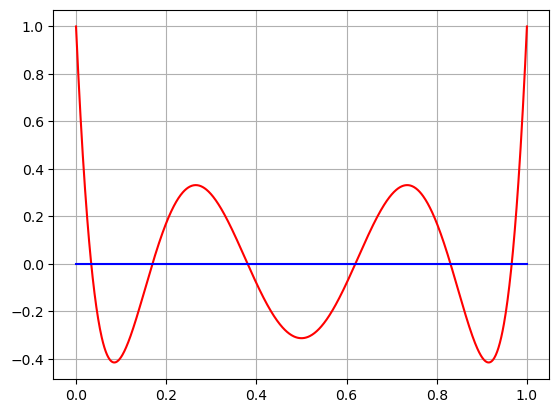

In [6]:
domain = np.linspace(0, 1, 1001)
P_list = P(domain)
y_zero = np.zeros(len(domain))
plt.plot(domain, P_list, color = 'red')
plt.plot(domain, y_zero, color = 'blue')
plt.grid()
plt.show()

In [9]:
guess = np.array([0.05, 0.15, 0.38, 0.62, 0.85, 0.95])
x_0 = np.copy(guess)
acc = 1e-10
err = 999.99
while err >= acc:
    delta = P(guess)/dP(guess)
    guess -= delta
    err = max(np.abs(delta))

print(x_0)
print(guess)

[0.05 0.15 0.38 0.62 0.85 0.95]
[0.03376524 0.16939531 0.38069041 0.61930959 0.83060469 0.96623476]


## Secant Method - The Lagrange Point (problem 6.17, page 273)

There is a magical point between the Earth and the Moon, called the $L_1$ Lagrange point, at which a satellite will orbit the Earth in perfect synchrony with the Moon, staying always in between the two.  This works because the inward pull of the Earth and the outward pull of the Moon combine to create exactly the needed centripetal force that keeps the satellite in its orbit.  The setup looks like this:



a) Assuming circular orbits, and assuming that the Earth is much more massive than either the Moon or the satellite, show that the distance $r$ from the center of the Earth to the $L_1$ point satisfies

$$ {GM\over r^2} - {Gm\over(R-r)^2} = \omega^2 r,$$

where $R$ is the distance from the Earth to the Moon, $M$ and $m$ are the Earth and Moon masses, $G$ is Newton's gravitational constant, and $\omega$ is the angular velocity of both the Moon and the satellite.

b) The equation above is a degree-five polynomial equation in $r$ (also called a quintic equation).  Such equations cannot be solved exactly in closed form, but it is straightforward to solve them numerically.  Write a program that uses the secant method to solve for the distance $r$ from the Earth to the $L_1$ point.  Compute a solution accurate to at least four significant figures.

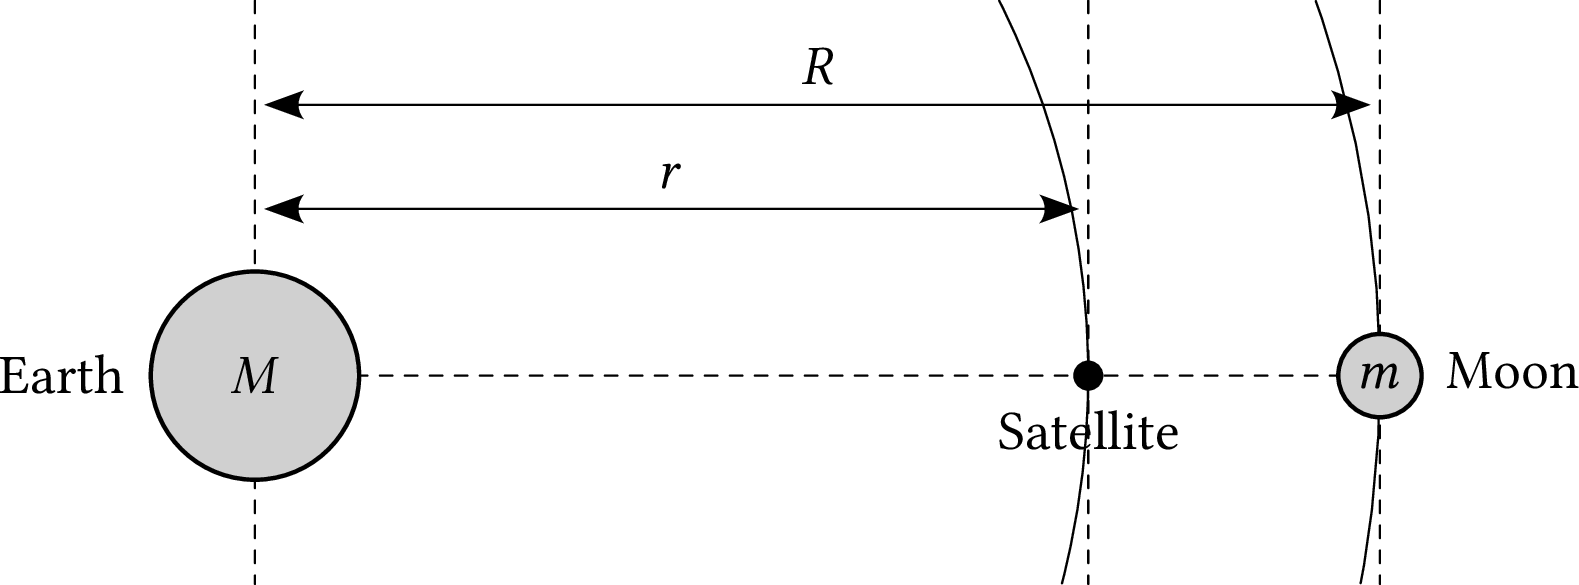

The values of the various parameters are:

$$G = 6.674\times10^{-11}\,\text{m}^3\text{kg}^{-1}\text{s}^{-2},$$

$$M = 5.974\times10^{24}\,\text{kg}, $$

$$m = 7.348\times10^{22}\,\text{kg}, $$

$$R = 3.844\times10^8\,\text{m}, $$

$$\omega = 2.662\times10^{-6}\,\text{s}^{-1}.$$

You will also need to choose a suitable starting value for $r$, or two starting values if you use the secant method.


## Newton's Method - many variable

Use Newton's Method to solve for the two variables $x$ and $y$ where
$$ x^3 +y = 1$$
$$y^3 - x = -1$$

To do this: 

1) Take the partial derivatives of the two equations - call the first equation $f(x,y)$ and the second $g(x,y)$, then take the partial derivatives of each with respect to $x$ and $y$. Write these equations in markdown. 

2) Write two functions `f(x,y)` and `g(x,y)` and define your target accuracy. 

3) Calculate and define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. 

4) Check your results for $x$ and $y$. Do they make sense? 


$$ f(x,y) = x^3 +y - 1 \qquad g(x,y) = y^3 - x + 1$$
$$\frac{\partial}{\partial x} f(x,y) = 3x^2 $$
$$\frac{\partial}{\partial y} f(x,y) = 1 $$
$$\frac{\partial}{\partial x} g(x,y) = -1 $$
$$\frac{\partial}{\partial y} g(x,y) = 3y^2 $$

In [15]:
def f(x,y):
    return x**3 +y -1
def g(x,y):
    return y**3 -x +1
acc = 1e-10
x, y = 1.0, 1.0

err = 999.99
while err > acc:
    J = np.array([[3*x**2, 1],[-1, 3*y**2]], float)
    v = np.array([f(x,y), g(x,y)], float)
    val = np.linalg.solve(J, v)
    x, y = x-val[0], y-val[1]
    err = np.sqrt(val[0]**2+val[1])
print(x,y)

1.0 -1.2525923223996593e-17
